In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import requests

# Folium library

We'll be using Folium, a mapping library. You may need to run the following cell (after un-commenting it) and restart the kernel.

In [169]:
#!pip install --user folium

In [170]:
import folium


# Capital Bikeshare Rides Data

Download the [2011 trip data](https://s3.amazonaws.com/capitalbikeshare-data/2011-capitalbikeshare-tripdata.zip) from [Capital Bikeshare](https://www.capitalbikeshare.com/system-data). Don't need to unzip the ZIP file; Pandas will handle it:

In [128]:
#rides = pd.read_csv("../hw6/2011-capitalbikeshare-tripdata.zip")
rides = pd.read_csv("../data/capital_bikeshare/2017Q1-capitalbikeshare-tripdata.csv")
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646510 entries, 0 to 646509
Data columns (total 9 columns):
Duration                646510 non-null int64
Start date              646510 non-null object
End date                646510 non-null object
Start station number    646510 non-null int64
Start station           646510 non-null object
End station number      646510 non-null int64
End station             646510 non-null object
Bike number             646510 non-null object
Member type             646510 non-null object
dtypes: int64(3), object(6)
memory usage: 44.4+ MB


In [129]:
print('{:,d}'.format(len(rides)))
rides.head()

646,510


,Duration,Start date,End date,Start station number,Start station,End station number,End station,Bike number,Member type
0,221,2017-01-01 00:00:41,2017-01-01 00:04:23,31634,3rd & Tingey St SE,31208,M St & New Jersey Ave SE,W00869,Member
1,1676,2017-01-01 00:06:53,2017-01-01 00:34:49,31258,Lincoln Memorial,31270,8th & D St NW,W00894,Casual
2,1356,2017-01-01 00:07:10,2017-01-01 00:29:47,31289,Henry Bacon Dr & Lincoln Memorial Circle NW,31222,New York Ave & 15th St NW,W21945,Casual
3,1327,2017-01-01 00:07:22,2017-01-01 00:29:30,31289,Henry Bacon Dr & Lincoln Memorial Circle NW,31222,New York Ave & 15th St NW,W20012,Casual
4,1636,2017-01-01 00:07:36,2017-01-01 00:34:52,31258,Lincoln Memorial,31270,8th & D St NW,W22786,Casual


In [130]:
rides['start_datetime'] = pd.to_datetime(rides['Start date'])
rides['start_hour'] = rides['start_datetime'].dt.hour

# Station Data
Let's get the [info about each station](https://gbfs.capitalbikeshare.com/gbfs/en/station_information.json).

Main things to notice in this section:

* **JSON is a useful format for structured data**.
* The `requests` library is a relatively easy way to automatically fetch data from the Web
* Pandas can make a DataFrame from a list of `dict`s.

In [131]:
station_info_response = requests.get("https://gbfs.capitalbikeshare.com/gbfs/en/station_information.json")
station_info_response_json = station_info_response.json()

In [132]:
stations = pd.DataFrame(station_info_response_json['data']['stations'])

In [133]:
print(len(stations), 'stations')
stations.head()

574 stations


,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id
0,19,False,[{'id': '5029b3a1-a049-46f9-a13c-c7ffef2bb88c'...,False,08249be7-1f3f-11e7-bf6b-3863bb334450,True,38.902221,-77.059219,Georgetown Harbor / 30th St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31215,72
1,23,False,[{'id': '6944e559-dc16-4a55-9125-e2c3256e294e'...,False,0824aa39-1f3f-11e7-bf6b-3863bb334450,True,38.900283,-77.029822,13th St & New York Ave NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31227,91
2,35,False,[{'id': '2a0089f1-ce95-4633-9471-61b0f70b7c08'...,False,0824c80d-1f3f-11e7-bf6b-3863bb334450,True,38.902061,-77.038322,17th & K St NW / Farragut Square,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31233,106
3,14,False,NaN,False,082469cc-1f3f-11e7-bf6b-3863bb334450,True,38.858971,-77.053230,Eads St & 15th St S,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31000,1
4,11,False,NaN,False,08246b69-1f3f-11e7-bf6b-3863bb334450,True,38.857250,-77.053320,18th St & S Eads St,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31001,2


In [134]:
stations['short_name'] = pd.to_numeric(stations['short_name'])

In [135]:
stations.query('short_name == 31620')

,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id
81,31,False,NaN,False,0824a28b-1f3f-11e7-bf6b-3863bb334450,True,38.897222,-77.019347,5th & F St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31620,82


# Adding traffic data
By "traffic" I mean ridership by station.


In [136]:
rides['am_pm'] = ["AM" if hour < 12 else "PM" for hour in rides['start_hour']]

In [138]:
traffic_data = pd.merge(
    rides.groupby(['Start station number', 'am_pm']).size().unstack(),
    rides.groupby(['End station number', 'am_pm']).size().unstack(),
    suffixes=["_departures", "_arrivals"],
    left_index=True, right_index=True
)

stations_with_traffic = pd.merge(
    stations,
    traffic_data,
    left_on="short_name", right_index=True,
    how='inner'
)
stations_with_traffic.head()

,capacity,eightd_has_key_dispenser,eightd_station_services,electric_bike_surcharge_waiver,external_id,has_kiosk,lat,lon,name,region_id,rental_methods,rental_url,short_name,station_id,AM_departures,PM_departures,AM_arrivals,PM_arrivals
0,19,False,[{'id': '5029b3a1-a049-46f9-a13c-c7ffef2bb88c'...,False,08249be7-1f3f-11e7-bf6b-3863bb334450,True,38.902221,-77.059219,Georgetown Harbor / 30th St NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31215,72,366.0,1822.0,1309.0,2063.0
1,23,False,[{'id': '6944e559-dc16-4a55-9125-e2c3256e294e'...,False,0824aa39-1f3f-11e7-bf6b-3863bb334450,True,38.900283,-77.029822,13th St & New York Ave NW,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31227,91,399.0,2411.0,1803.0,1391.0
2,35,False,[{'id': '2a0089f1-ce95-4633-9471-61b0f70b7c08'...,False,0824c80d-1f3f-11e7-bf6b-3863bb334450,True,38.902061,-77.038322,17th & K St NW / Farragut Square,42,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31233,106,603.0,2937.0,2248.0,1738.0
3,14,False,NaN,False,082469cc-1f3f-11e7-bf6b-3863bb334450,True,38.858971,-77.053230,Eads St & 15th St S,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31000,1,138.0,161.0,56.0,224.0
4,11,False,NaN,False,08246b69-1f3f-11e7-bf6b-3863bb334450,True,38.857250,-77.053320,18th St & S Eads St,41,"[KEY, CREDITCARD]",http://app.capitalbikeshare.com/vIiR/zVsfTIsOT...,31001,2,130.0,255.0,109.0,264.0


# Viewing data on a map

Main things to notice:
* **latitude and longitude** are the main two things you need for displaying map data.
* Geographic data usually needs a **base map** to be useful. Different base maps are useful in different circumstances
* Map data, especially base maps, may be proprietary (needs license keys).

In [139]:
# Try un-commenting the different "tiles" lines, one at a time.
folium.Map(
    location=[42.961111, -85.655556],
    #tiles='Stamen Toner',
    #tiles="CartoDB positron",
    #tiles="CartoDB dark_matter",
    zoom_start=13
)

Now here's how we can add our stations:

In [147]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations_with_traffic.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        radius=2
    ).add_to(m)

display(m)

# Coloring data by region

We need to manually specify what colors to use. 

We'll pick a color scheme from [ColorBrewer](http://colorbrewer2.org/#type=qualitative&scheme=Paired&n=6).

Notice that there are 3 different types of color schemes:
* diverging
* sequential
* qualitative

Note also that we often express colors in hexadecimal (red-green-blue, two hex digits each).

['#a6cee3',
 '#1f78b4',
 '#b2df8a',
 '#33a02c',
 '#fb9a99',
 '#e31a1c',
 '#fdbf6f',
 '#ff7f00',
 '#cab2d6',
 '#6a3d9a',
 '#ffff99',
 '#b15928']

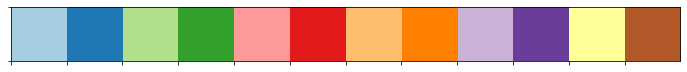

In [150]:
colors = sns.color_palette("Paired")
sns.palplot(colors)
color_codes = colors.as_hex()
color_codes

The `stations` data includes a `region_id`, which looks like it might identify which geographic region a station is in.

In [151]:
stations.region_id.value_counts()

42     302
41      92
44      46
43      36
104     34
40      31
133     23
152     10
Name: region_id, dtype: int64

In [152]:
def assign_colors(ids):
    color_for_id = {}
    next_color_idx = 0
    colors = []
    for x in ids:
        if x not in color_for_id:
            color_for_id[x] = color_codes[next_color_idx]
            next_color_idx += 1
        colors.append(color_for_id[x])
    return colors

In [153]:
stations['marker_color'] = assign_colors(stations.region_id)

In [154]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

display(m)

# Data organized by regions are useful for analysis

In [158]:
(
    stations_with_traffic
    .groupby('region_id')
    [['AM_departures', 'AM_arrivals', 'PM_departures', 'PM_arrivals']]
    .mean()
    .style.bar()
)

,AM_departures,AM_arrivals,PM_departures,PM_arrivals
region_id,,,,
40,157.065,143.742,292.032,315.903
41,207.598,166.322,341.138,349.494
42,762.174,780.745,1589.77,1580.06
43,25.6316,25.5789,40.9048,40.5238
44,80.6047,53.4524,124.023,141.837
104,22.5,20.1364,38,37.8636


# Clustering

What if the data didn't come with `region_id`? We could use *clustering* to discover spatially similar regions.

There are many different kinds of clustering algorithms, but *k-means* is a very common one because it's simple and often works reasonably.


In [159]:
from sklearn.cluster import KMeans

One downside of k-means is we need to tell it how many clusters to look for.

In [160]:
km = KMeans(n_clusters=8)

In [188]:
# We'll use the latitude and longitude as features to cluster by.
# np.c_[] constructs a 2D array from columns.
X = np.c_[
    10.0 * stations_with_traffic['lat'],
    1.0 * stations_with_traffic['lon']
]
X.shape

(448, 2)

In [189]:
# clustering objects have a similar interface to classifiers:
km.fit(X)

stations_with_traffic['kmeans(8)_cluster'] = km.predict(X)

stations_with_traffic['kmeans(8)_cluster'].value_counts()

1    177
4     83
3     58
0     37
7     35
5     30
2     21
6      7
Name: kmeans(8)_cluster, dtype: int64

In [190]:
stations_with_traffic['marker_color'] = assign_colors(stations_with_traffic['kmeans(8)_cluster'])

In [193]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations_with_traffic.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

for cluster_center in km.cluster_centers_:
    folium.CircleMarker(
        location=cluster_center,
        radius=10,
        fill="red"
    ).add_to(m)
    
display(m)

In [164]:
len(stations)

574

In [165]:
len(stations_with_traffic)

448

In [166]:
len(traffic_data)

452

In [117]:
m = folium.Map(
    location=[39, -77.],
    tiles='Stamen Toner',
    zoom_start=10
)

for station in stations_with_traffic.itertuples():
    folium.CircleMarker(
        location=[station.lat, station.lon],
        tooltip=station.name,
        color=station.marker_color,
        radius=2
    ).add_to(m)

for cluster_center in km.cluster_centers_:
    folium.CircleMarker(
        location=cluster_center,
        radius=10,
        fill="red"
    ).add_to(m)
    
display(m)

In [118]:
stations_with_traffic.groupby('kmeans(8)_cluster')[['num_morning_departures', 'num_morning_arrivals']].mean().style.bar()

,num_morning_departures,num_morning_arrivals
kmeans(8)_cluster,,
0,929.212,1058.85
1,120.371,79
2,23.8182,23.0909
3,227.343,184.443
4,24,17.9
5,162.981,158.811
6,615.829,429.214
7,27.4706,28.1176
